# Exploratory Data Analysis (EDA)

Before architecting our forecasting pipeline, we must deeply understand the data generating process. Retail data is notoriously noisy, intermittent, and heavily skewed. This EDA serves as a mandatory sanity check and strategic planning phase to inform our model selection.

### Analytical Objectives:
1. **Data Integrity & Volume**: Validate schema, time horizons, and isolate valid demand signals from administrative noise (returns/cancellations).
2. **Pareto Dynamics (Volume vs. Revenue)**: Identify the blockbuster SKUs driving the business vs. the long-tail inventory.
3. **Geographical & Customer Bias**: Assess spatial distribution to determine if global forecasting is viable or if we should restrict scope to the UK market.
4. **Macro-Seasonality & Stationarity**: Visually inspect the overall demand time series for structural breaks and extreme seasonal peaks (e.g., Q4 Christmas effect).
5. **Demand Intermittency (Syntetos-Boylan)**: Classify SKU behavior into Smooth, Erratic, or Intermittent profiles to justify the need for advanced ML algorithms (like Tweedie-objective LightGBM) over standard ARIMA.
6. **Price Elasticity & Commercial Tiers**: Map the price distribution to inform downstream categorical feature engineering.

In [11]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.tools import (
    load_raw_data, clean_and_split_transactions,
    aggregate_weekly_sku, add_pricing_features,
    calculate_demand_profile, calculate_commercial_profile,
)

## 1. Shape, time range, sheet split

In [12]:
df = load_raw_data(ROOT / "data" / "raw" / "online_retail_II.xlsx")
print("shape:", df.shape)
print("time range:", df['InvoiceDate'].min(), "→", df['InvoiceDate'].max())
print("\nnulls:")
print(df.isna().sum())

shape: (1067371, 8)
time range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00

nulls:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [13]:
# Isolate true demand (sales) from reverse logistics (returns)
sales, returns = clean_and_split_transactions(df, verbose=False)

print(f"Sales Records: {len(sales):,} | Unique SKUs: {sales['StockCode'].nunique():,}")
print(f"Return Records: {len(returns):,} | Total Units Returned: {abs(returns['Quantity'].sum()):,}")
print(f"Signal-to-Noise Ratio (Valid Rows): {(len(sales)+len(returns))/len(df):.1%}")

Sales Records: 1,035,620 | Unique SKUs: 4,873
Return Records: 18,176 | Total Units Returned: 481,025
Signal-to-Noise Ratio (Valid Rows): 98.7%


## 2. The Pareto Principle: Top SKUs by Revenue & Volume

In e-commerce, the catalog rarely follows a uniform distribution. We expect a steep Pareto curve (the 80/20 rule) where a fraction of "blockbuster" items drives the majority of revenue, while a massive "long tail" of intermittent SKUs generates noise. 
Identifying these top movers is crucial, as their forecasting accuracy disproportionately impacts the final business value and aggregate MAPE.

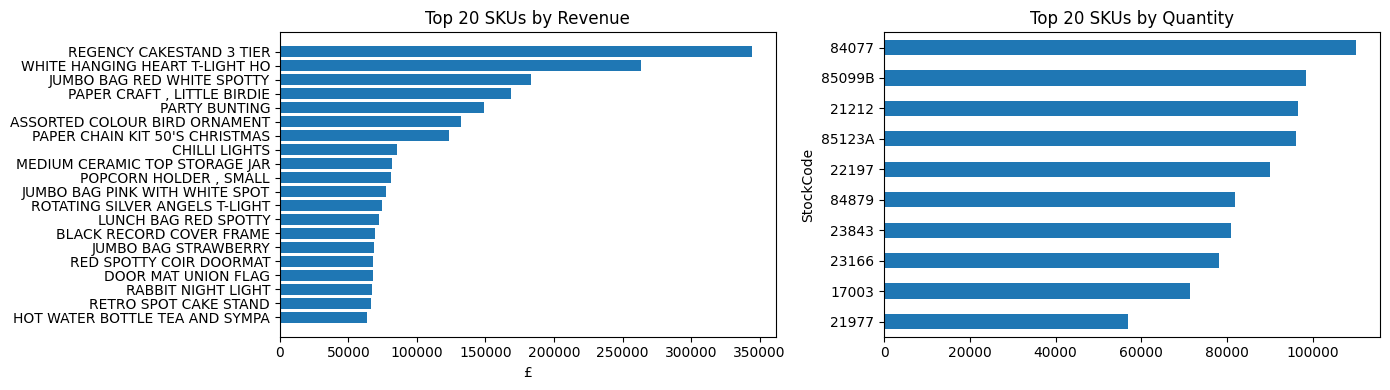

In [14]:
weekly = aggregate_weekly_sku(sales)
by_rev = weekly.groupby('StockCode')['Revenue'].sum().sort_values(ascending=False)
by_vol = weekly.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False)

top_rev = by_rev.head(20).reset_index()
top_rev = top_rev.merge(
    sales.groupby('StockCode')['Description'].first().reset_index(),
    on='StockCode'
)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].barh(top_rev['Description'].str[:30][::-1], top_rev['Revenue'][::-1])
ax[0].set_title('Top 20 SKUs by Revenue'); ax[0].set_xlabel('£')
by_vol.head(10).plot.barh(ax=ax[1])
ax[1].set_title('Top 20 SKUs by Quantity'); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

## 3. Spatial Distribution & Customer Density

Global macro-economic factors and distinct national holidays heavily influence demand. If a single country completely dominates the dataset, training a global model might dilute the primary signal. Here, we assess the geographical skew and evaluate the prevalence of "anonymous" guest checkouts versus registered customers to understand data quality.

In [15]:
country_share = sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
print(f"UK share of total revenue: {country_share['United Kingdom'] / country_share.sum():.1%}")
print("\nTop 10 countries by revenue:")
print(country_share.head(10).round(0))

n_customers = sales['Customer ID'].nunique()
n_anon = sales['Customer ID'].isna().sum()
print(f"\nunique customers (named): {n_customers:,}  |  anonymous rows: {n_anon:,} ({n_anon/len(sales):.1%})")

UK share of total revenue: 85.7%

Top 10 countries by revenue:
Country
United Kingdom    17179285.0
EIRE                625298.0
Netherlands         549953.0
Germany             387426.0
France              315336.0
Australia           168467.0
Spain                98613.0
Switzerland          94199.0
Sweden               86353.0
Denmark              68560.0
Name: Revenue, dtype: float64

unique customers (named): 5,852  |  anonymous rows: 234,061 (22.6%)


## 4. Macro-Seasonality & Structural Demand Shocks

Time series models rely heavily on historical patterns. By aggregating total sales and revenue across the timeline, we can visually test for **stationarity** (is the mean constant over time?) and identify structural seasonal shocks. 

Since this retailer specializes in gift-ware, we anticipate severe non-stationarity driven by a massive Q4 (Nov/Dec) holiday spike. Identifying this explicitly confirms the necessity of injecting UK Bank Holidays and localized calendar features into our modeling pipeline to help tree-based models anticipate these peaks.

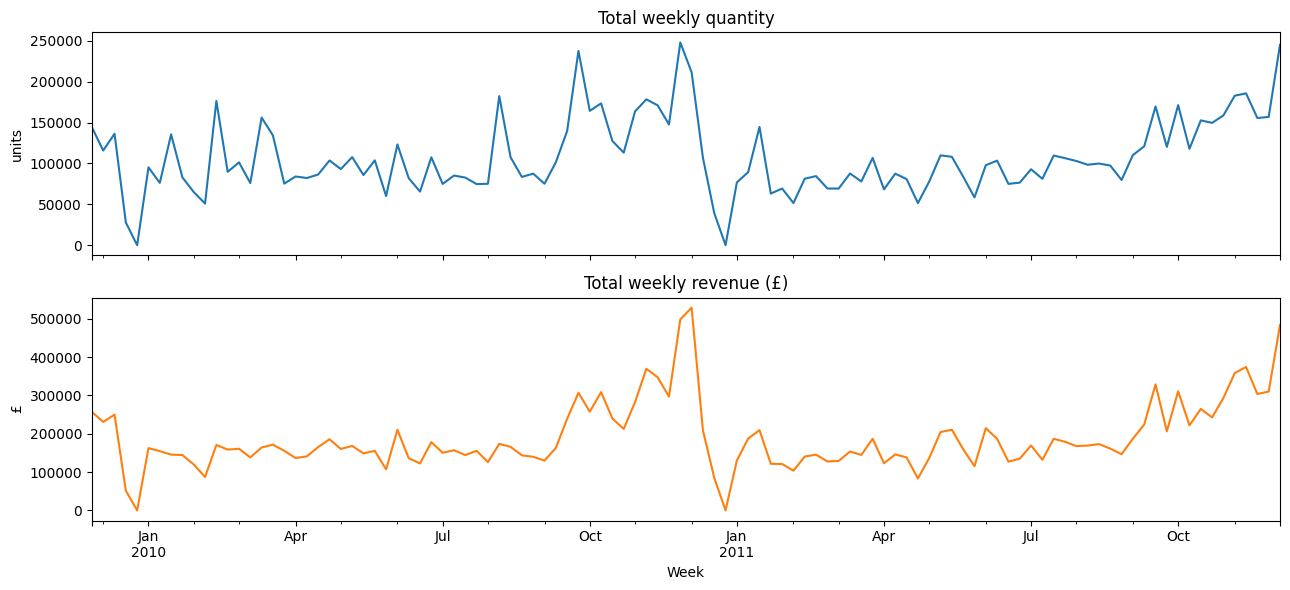

In [16]:
wk_total = weekly.groupby('Week').agg(Quantity=('Quantity', 'sum'), Revenue=('Revenue', 'sum'))
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
wk_total['Quantity'].plot(ax=ax[0]); ax[0].set_title('Total weekly quantity'); ax[0].set_ylabel('units')
wk_total['Revenue'].plot(ax=ax[1], color='tab:orange'); ax[1].set_title('Total weekly revenue (£)'); ax[1].set_ylabel('£')
plt.tight_layout(); plt.show()

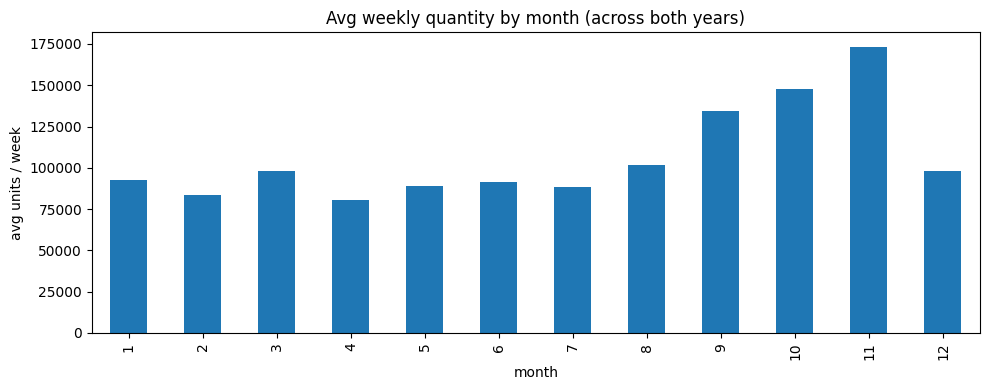

Peak month: 11   multiplier vs Jan: 1.87


In [17]:
wk_total = wk_total.copy()
wk_total['month'] = wk_total.index.month
monthly = wk_total.groupby('month')['Quantity'].mean()
ax = monthly.plot.bar(figsize=(10, 4), title='Avg weekly quantity by month (across both years)')
ax.set_xlabel('month'); ax.set_ylabel('avg units / week')
plt.tight_layout(); plt.show()
print("Peak month:", int(monthly.idxmax()), "  multiplier vs Jan:", round(monthly.max() / monthly[1], 2))

## 5. SKU Demand Profiling (Syntetos-Boylan Classification)

Not all time series are created equal. Forecasting daily bread sales is trivial; forecasting high-ticket, sporadic items is notoriously difficult. We apply the **Syntetos-Boylan approximation**, categorizing SKUs based on two statistical dimensions:
1. **ADI (Average Demand Interval):** Time between consecutive sales.
2. **CV² (Squared Coefficient of Variation):** Volatility of the sale quantities.

This classification dictates our model selection:
* **Smooth (Low ADI, Low CV²):** Traditional models (SARIMAX, Prophet) excel here.
* **Erratic (Low ADI, High CV²):** Consistent timing, highly variable sizes. Requires robust ML algorithms handling skewness (e.g., LightGBM with Tweedie loss).
* **Intermittent / Lumpy (High ADI):** Sparse datasets heavily populated with zeros. Deep Learning architectures (DeepAR) and specialized zero-inflated models are required to prevent massive over-forecasting.

demand_class
lumpy           3149
intermittent     946
erratic          716
smooth            62
Name: count, dtype: int64 



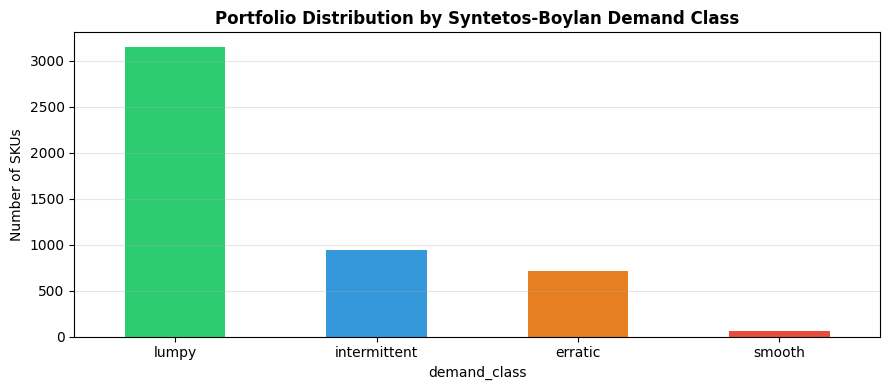

,StockCode,ADI,CV2,demand_class,share_zero_weeks
0,10002,1.514286,2.232535,lumpy,0.339623
1,10002R,35.333333,0.125000,intermittent,0.971698
2,10080,5.300000,0.810632,lumpy,0.811321
3,10109,106.000000,0.000000,intermittent,0.990566
4,10120,2.523810,1.437344,lumpy,0.603774


In [18]:
# Utilizing our modular tool to calculate ADI, CV2, and demand classes
demand_df = calculate_demand_profile(weekly)

print(demand_df['demand_class'].value_counts(), "\n")

fig, ax = plt.subplots(figsize=(9, 4))
demand_df['demand_class'].value_counts().plot.bar(
    color=['#2ecc71', '#3498db', '#e67e22', '#e74c3c'], ax=ax
)
ax.set_title('Portfolio Distribution by Syntetos-Boylan Demand Class', fontweight='bold')
ax.set_ylabel('Number of SKUs')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

demand_df.head()

Return Rate Distribution (Percentiles):
count    4887.000
mean        0.030
std         0.097
min         0.000
50%         0.004
75%         0.020
90%         0.063
95%         0.130
99%         0.486
max         1.000
Name: return_rate, dtype: float64


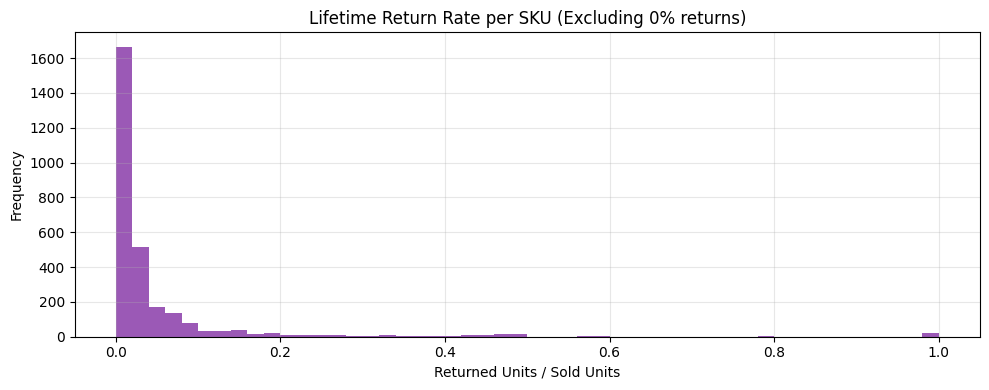

In [19]:
# Calculate lifetime return rate manually to audit data quality
sold = sales.groupby('StockCode')['Quantity'].sum().rename('qty_sold')
# Returns are negative quantities, so we take the absolute sum
returned = returns.groupby('StockCode')['Quantity'].sum().abs().rename('qty_returned')

rr_df = pd.concat([sold, returned], axis=1).fillna(0)

# Calculate Return Rate (avoiding division by zero for items never technically sold but returned)
rr_df['return_rate'] = np.where(
    rr_df['qty_sold'] > 0, 
    rr_df['qty_returned'] / rr_df['qty_sold'], 
    0
)
# Clip anomalies where returns exceed sales (due to cross-year boundary effects)
rr_df['return_rate'] = rr_df['return_rate'].clip(0, 1)

print("Return Rate Distribution (Percentiles):")
print(rr_df['return_rate'].describe(percentiles=[.5, .75, .9, .95, .99]).round(3))

fig, ax = plt.subplots(figsize=(10, 4))
rr_df[rr_df['return_rate'] > 0]['return_rate'].plot.hist(bins=50, ax=ax, color='#9b59b6')
ax.set_title('Lifetime Return Rate per SKU (Excluding 0% returns)')
ax.set_xlabel('Returned Units / Sold Units')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Commercial Profiling & Price Segmentation

Price points dictate consumer behavior. A £1 trinket acts as an impulse buy (high volume, smooth demand), whereas a £50 decor piece faces price elasticity and seasonal scrutiny. By calculating the median static price and classifying SKUs into discrete financial tiers, we construct powerful categorical features. These allow tree-based algorithms to learn varying elasticities across different segments of the portfolio.

Commercial Profile Summary:
       price_median  mean_basket_size  n_unique_customers  country_uk_share
count       4873.00           4873.00             4873.00           4873.00
mean           3.99             29.52               98.60              0.94
std            8.31           1161.51              133.64              0.08
min            0.04              1.00                0.00              0.00
25%            1.25              2.86               12.00              0.91
50%            2.11              5.95               46.00              0.95
75%            4.25             10.76              130.00              0.99
max          295.00          80995.00             1490.00              1.00


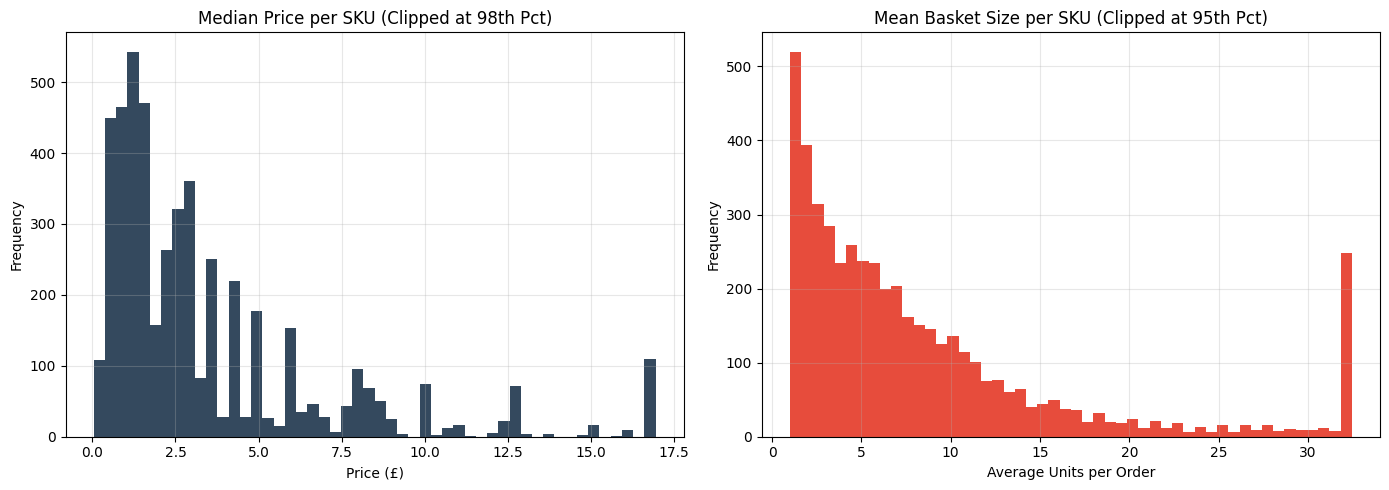

In [20]:
# Extract commercial metadata utilizing our custom tool
comm = calculate_commercial_profile(sales)

print("Commercial Profile Summary:")
print(comm[['price_median', 'mean_basket_size', 'n_unique_customers', 'country_uk_share']].describe().round(2))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Price Distribution (Clipped to remove luxury outliers for visibility)
clipped_price = comm['price_median'].clip(upper=comm['price_median'].quantile(0.98))
clipped_price.plot.hist(bins=50, ax=ax[0], color='#34495e')
ax[0].set_title('Median Price per SKU (Clipped at 98th Pct)')
ax[0].set_xlabel('Price (£)')
ax[0].grid(alpha=0.3)

# Plot 2: Mean Basket Size Distribution
# Using a histogram instead of a bar chart because mean_basket_size is a continuous float, not categorical.
# We clip at the 95th percentile to avoid massive wholesale orders squashing the distribution.
clipped_basket = comm['mean_basket_size'].clip(upper=comm['mean_basket_size'].quantile(0.95))
clipped_basket.plot.hist(bins=50, ax=ax[1], color='#e74c3c')
ax[1].set_title('Mean Basket Size per SKU (Clipped at 95th Pct)')
ax[1].set_xlabel('Average Units per Order')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()